Please upload an image:


Saving 2026UUE0379_VIKAS.jpg to 2026UUE0379_VIKAS.jpg

Uploaded image: 2026UUE0379_VIKAS.jpg
Image shape: (1445, 1088, 3)



TRANSFORMATION RESULTS


A1 - Scaling

Matrix A =
[[2.  0. ]
 [0.  0.5]]

T(e1) = [2. 0.]
T(e2) = [0.  0.5]

Rank(A) = 2
Dimension/information lost: NO

Visual effect:
The image becomes twice as wide and half as high.

Connection with columns of A:
Column 1 maps e1 to (2,0), stretching x; column 2 maps e2 to (0,0.5), shrinking y.


A2 - 90 degree rotation

Matrix A =
[[ 0. -1.]
 [ 1.  0.]]

T(e1) = [0. 1.]
T(e2) = [-1.  0.]

Rank(A) = 2
Dimension/information lost: NO

Visual effect:
The image rotates 90 degrees counter-clockwise.

Connection with columns of A:
Column 1 maps e1 to (0,1) and column 2 maps e2 to (-1,0), producing a 90 degree rotation.


A3 - Horizontal shear

Matrix A =
[[1. 1.]
 [0. 1.]]

T(e1) = [1. 0.]
T(e2) = [1. 1.]

Rank(A) = 2
Dimension/information lost: NO

Visual effect:
The image is sheared horizontally; vertical lines tilt.

Connection wi

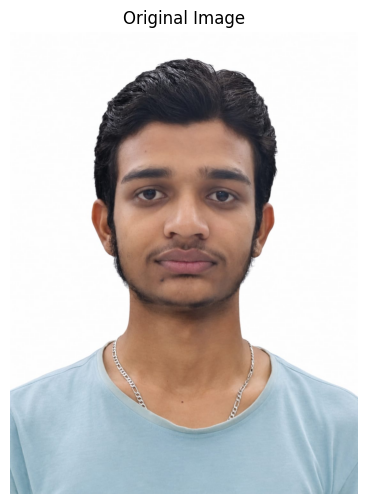

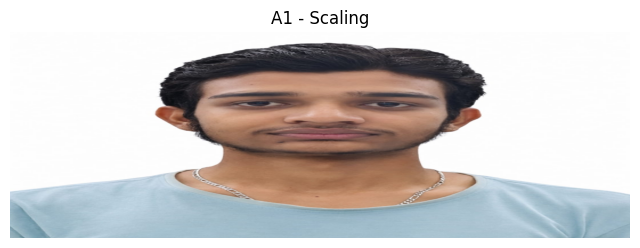

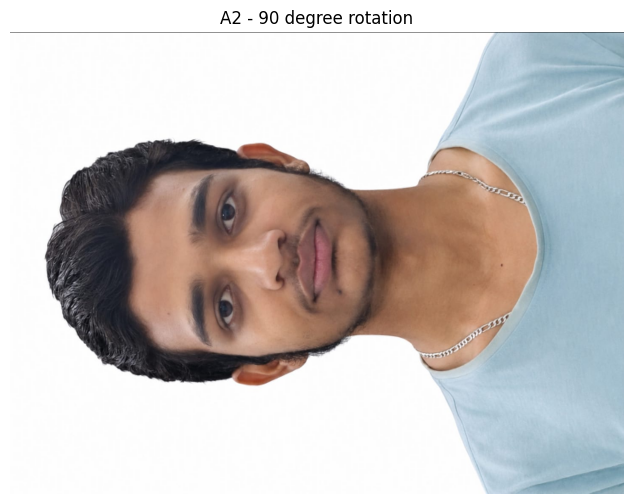

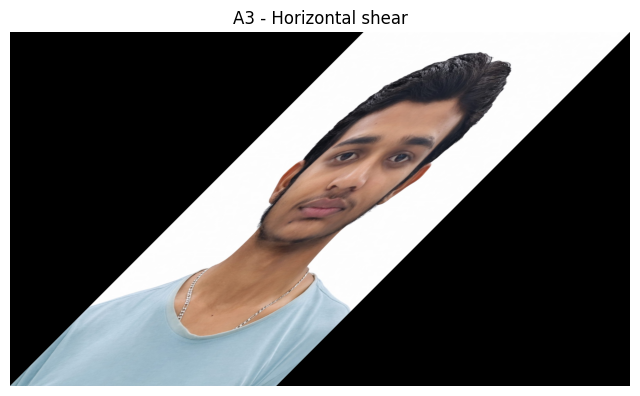

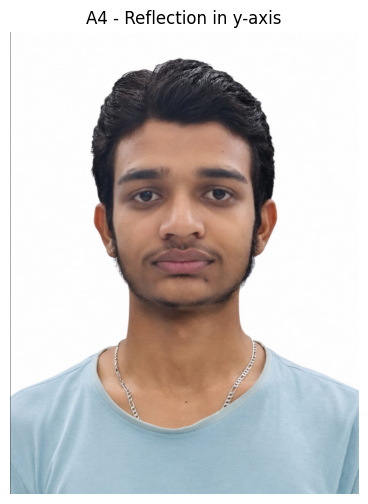

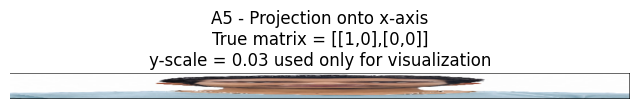



FINAL SUMMARY

A1:
T(e1) = (2, 0)
T(e2) = (0, 0.5)
Rank = 2
Information lost = No
Effect = x stretched by 2, y compressed by 0.5

A2:
T(e1) = (0, 1)
T(e2) = (-1, 0)
Rank = 2
Information lost = No
Effect = 90 degree counter-clockwise rotation

A3:
T(e1) = (1, 0)
T(e2) = (1, 1)
Rank = 2
Information lost = No
Effect = horizontal shear

A4:
T(e1) = (-1, 0)
T(e2) = (0, 1)
Rank = 2
Information lost = No
Effect = reflection in y-axis

A5:
T(e1) = (1, 0)
T(e2) = (0, 0)
Rank = 1
Information lost = YES
Effect = projection onto x-axis

IMPORTANT:
For A5 the true matrix is

[[1, 0],
 [0, 0]]

A small y-scale of 0.03 was used ONLY to make
the projected image visible.



In [1]:
# Q10 - PYTHON: TRANSFORM AN ACTUAL IMAGE
# Complete Google Colab Code


import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files



# 1. UPLOAD IMAGE


print("Please upload an image:")
uploaded = files.upload()

# Automatically get uploaded image filename
image_path = list(uploaded.keys())[0]

# Load image
img = Image.open(image_path).convert("RGB")
img = np.array(img)

print("\nUploaded image:", image_path)
print("Image shape:", img.shape)



# 2. DEFINE TRANSFORMATION MATRICES


A1 = np.array([
    [2,   0],
    [0, 0.5]
], dtype=float)

A2 = np.array([
    [0, -1],
    [1,  0]
], dtype=float)

A3 = np.array([
    [1, 1],
    [0, 1]
], dtype=float)

A4 = np.array([
    [-1, 0],
    [ 0, 1]
], dtype=float)

A5 = np.array([
    [1, 0],
    [0, 0]
], dtype=float)


transformations = [
    ("A1 - Scaling", A1),
    ("A2 - 90 degree rotation", A2),
    ("A3 - Horizontal shear", A3),
    ("A4 - Reflection in y-axis", A4),
    ("A5 - Projection onto x-axis", A5)
]


# 3. STANDARD BASIS VECTORS

e1 = np.array([1, 0], dtype=float)
e2 = np.array([0, 1], dtype=float)



# 4. FUNCTION TO TRANSFORM IMAGE

def transform_image(image, A, is_projection=False):

    h, w = image.shape[:2]


    # A5 has zero y-scale, so the actual image becomes a line.
    # For visualization only, use a very small y-scale.

    if is_projection:

        A_display = np.array([
            [1, 0],
            [0, 0.03]
        ], dtype=float)

    else:
        A_display = A.copy()


    # Image centre
    cx = (w - 1) / 2
    cy = (h - 1) / 2



    # Original image corner coordinates


    corners_pixel = np.array([
        [0, 0],
        [w - 1, 0],
        [0, h - 1],
        [w - 1, h - 1]
    ], dtype=float)


    # Convert pixel coordinates to mathematical coordinates
    # Origin = image centre
    # x positive -> right
    # y positive -> upward

    corners_math = np.zeros_like(corners_pixel)

    corners_math[:, 0] = corners_pixel[:, 0] - cx
    corners_math[:, 1] = cy - corners_pixel[:, 1]


    # Apply transformation
    transformed_corners = corners_math @ A_display.T


    # Find output image boundaries
    min_x = np.floor(transformed_corners[:, 0].min())
    max_x = np.ceil(transformed_corners[:, 0].max())

    min_y = np.floor(transformed_corners[:, 1].min())
    max_y = np.ceil(transformed_corners[:, 1].max())


    new_width = max(1, int(max_x - min_x + 1))
    new_height = max(1, int(max_y - min_y + 1))


    # Empty transformed image
    output = np.zeros(
        (new_height, new_width, 3),
        dtype=np.uint8
    )


    # --------------------------------------------------------
    # INVERSE MAPPING
    # --------------------------------------------------------

    # Coordinates of every output pixel
    yy, xx = np.indices((new_height, new_width))


    # Convert output pixels into transformed mathematical coords
    x_new = xx + min_x
    y_new = max_y - yy


    transformed_points = np.stack(
        (x_new.ravel(), y_new.ravel()),
        axis=1
    )


    # Inverse of transformation matrix
    A_inv = np.linalg.inv(A_display)


    # Find original coordinates
    original_math = transformed_points @ A_inv.T


    # Convert mathematical coordinates back to pixel coordinates
    original_x = np.rint(
        original_math[:, 0] + cx
    ).astype(int)

    original_y = np.rint(
        cy - original_math[:, 1]
    ).astype(int)


    # Check pixels that lie inside original image
    valid = (
        (original_x >= 0) &
        (original_x < w) &
        (original_y >= 0) &
        (original_y < h)
    )


    # Copy pixel colours
    output_flat = output.reshape(-1, 3)

    output_flat[valid] = image[
        original_y[valid],
        original_x[valid]
    ]

    return output


# ============================================================
# 5. EXPLANATIONS
# ============================================================

visual_effect = {

    "A1 - Scaling":
    "The image becomes twice as wide and half as high.",

    "A2 - 90 degree rotation":
    "The image rotates 90 degrees counter-clockwise.",

    "A3 - Horizontal shear":
    "The image is sheared horizontally; vertical lines tilt.",

    "A4 - Reflection in y-axis":
    "The image is reflected left-to-right across the y-axis.",

    "A5 - Projection onto x-axis":
    "The image collapses onto the x-axis, so vertical information is lost."
}


column_effect = {

    "A1 - Scaling":
    "Column 1 maps e1 to (2,0), stretching x; "
    "column 2 maps e2 to (0,0.5), shrinking y.",

    "A2 - 90 degree rotation":
    "Column 1 maps e1 to (0,1) and column 2 maps "
    "e2 to (-1,0), producing a 90 degree rotation.",

    "A3 - Horizontal shear":
    "Column 1 keeps e1 unchanged, while column 2 maps "
    "e2 to (1,1), creating a horizontal shear.",

    "A4 - Reflection in y-axis":
    "Column 1 maps e1 to (-1,0), reversing x, while "
    "column 2 keeps e2 unchanged.",

    "A5 - Projection onto x-axis":
    "Column 1 keeps e1, while column 2 maps e2 to zero; "
    "therefore all vertical information is lost."
}


# ============================================================
# 6. PRINT T(e1), T(e2), RANK AND INFORMATION LOSS
# ============================================================

print("\n\n")
print("=" * 70)
print("TRANSFORMATION RESULTS")
print("=" * 70)


for name, A in transformations:

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)

    print("\nMatrix A =")
    print(A)

    Te1 = A @ e1
    Te2 = A @ e2

    print("\nT(e1) =", Te1)
    print("T(e2) =", Te2)

    rank = np.linalg.matrix_rank(A)

    print("\nRank(A) =", rank)

    if rank == 2:
        print("Dimension/information lost: NO")
    else:
        print("Dimension/information lost: YES")

    print("\nVisual effect:")
    print(visual_effect[name])

    print("\nConnection with columns of A:")
    print(column_effect[name])


# ============================================================
# 7. DISPLAY ORIGINAL IMAGE
# ============================================================

plt.figure(figsize=(8, 6))

plt.imshow(img)

plt.title("Original Image")

plt.axis("off")

plt.show()


# ============================================================
# 8. APPLY AND DISPLAY ALL TRANSFORMATIONS
# ============================================================

for name, A in transformations:

    # A5 requires small nonzero y-scale only for display
    if name.startswith("A5"):

        transformed = transform_image(
            img,
            A,
            is_projection=True
        )

    else:

        transformed = transform_image(
            img,
            A
        )


    plt.figure(figsize=(8, 6))

    plt.imshow(transformed)


    if name.startswith("A5"):

        plt.title(
            "A5 - Projection onto x-axis\n"
            "True matrix = [[1,0],[0,0]]\n"
            "y-scale = 0.03 used only for visualization"
        )

    else:

        plt.title(name)


    plt.axis("off")

    plt.show()


# ============================================================
# 9. FINAL SUMMARY TABLE
# ============================================================

print("\n")
print("=" * 90)
print("FINAL SUMMARY")
print("=" * 90)

print("""
A1:
T(e1) = (2, 0)
T(e2) = (0, 0.5)
Rank = 2
Information lost = No
Effect = x stretched by 2, y compressed by 0.5

A2:
T(e1) = (0, 1)
T(e2) = (-1, 0)
Rank = 2
Information lost = No
Effect = 90 degree counter-clockwise rotation

A3:
T(e1) = (1, 0)
T(e2) = (1, 1)
Rank = 2
Information lost = No
Effect = horizontal shear

A4:
T(e1) = (-1, 0)
T(e2) = (0, 1)
Rank = 2
Information lost = No
Effect = reflection in y-axis

A5:
T(e1) = (1, 0)
T(e2) = (0, 0)
Rank = 1
Information lost = YES
Effect = projection onto x-axis

IMPORTANT:
For A5 the true matrix is

[[1, 0],
 [0, 0]]

A small y-scale of 0.03 was used ONLY to make
the projected image visible.
""")


In [1]:
# ============================================================
# Q11 - INTERACTIVE IMAGE TRANSFORMATION TOOLBOX
# Google Colab - Complete Code in ONE CELL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO

import ipywidgets as widgets
from IPython.display import display, clear_output


# ============================================================
# GLOBAL VARIABLES
# ============================================================

original_image = None
current_image = None


# ============================================================
# FUNCTION: GENERAL 2D MATRIX TRANSFORMATION
# ============================================================

def linear_transform(image, A):
    """
    Apply a 2x2 linear transformation about the image centre.

    Coordinates are treated mathematically:
        +x -> right
        +y -> upward
    """

    img = np.array(image.convert("RGB"))

    h, w = img.shape[:2]

    # Centre of image
    cx = (w - 1) / 2
    cy = (h - 1) / 2

    # Four image corners
    corners_pixel = np.array([
        [0, 0],
        [w - 1, 0],
        [0, h - 1],
        [w - 1, h - 1]
    ], dtype=float)

    # Convert pixel coordinates to mathematical coordinates
    corners_math = np.zeros_like(corners_pixel)

    corners_math[:, 0] = corners_pixel[:, 0] - cx
    corners_math[:, 1] = cy - corners_pixel[:, 1]

    # Apply matrix transformation
    transformed_corners = corners_math @ A.T

    # Find new image boundaries
    min_x = np.floor(transformed_corners[:, 0].min())
    max_x = np.ceil(transformed_corners[:, 0].max())

    min_y = np.floor(transformed_corners[:, 1].min())
    max_y = np.ceil(transformed_corners[:, 1].max())

    new_width = max(1, int(max_x - min_x + 1))
    new_height = max(1, int(max_y - min_y + 1))

    # White output image
    output = np.ones(
        (new_height, new_width, 3),
        dtype=np.uint8
    ) * 255

    # Coordinates of output image
    yy, xx = np.indices((new_height, new_width))

    # Convert to mathematical coordinates
    x_new = xx + min_x
    y_new = max_y - yy

    transformed_points = np.stack(
        [x_new.ravel(), y_new.ravel()],
        axis=1
    )

    # Pseudo-inverse also works for some singular matrices
    A_inverse = np.linalg.pinv(A)

    # Find corresponding points in original image
    original_math = transformed_points @ A_inverse.T

    original_x = np.rint(
        original_math[:, 0] + cx
    ).astype(int)

    original_y = np.rint(
        cy - original_math[:, 1]
    ).astype(int)

    # Keep only valid pixels
    valid = (
        (original_x >= 0) &
        (original_x < w) &
        (original_y >= 0) &
        (original_y < h)
    )

    output_flat = output.reshape(-1, 3)

    output_flat[valid] = img[
        original_y[valid],
        original_x[valid]
    ]

    return Image.fromarray(output)


# ============================================================
# FUNCTION: DISPLAY CURRENT IMAGE
# ============================================================

def show_current_image(title="Current Image"):

    if current_image is None:
        return

    plt.figure(figsize=(8, 6))

    plt.imshow(current_image)

    plt.title(
        f"{title}\n"
        f"Size = {current_image.width} × {current_image.height}"
    )

    plt.axis("off")
    plt.show()


# ============================================================
# IMAGE UPLOAD WIDGET
# ============================================================

upload_widget = widgets.FileUpload(
    accept=".jpg,.jpeg,.png",
    multiple=False,
    description="Upload Image"
)


# ============================================================
# OPERATION MENU
# ============================================================

operation_menu = widgets.Dropdown(

    options=[
        "Rotate",
        "Resize",
        "Flip",
        "Shear",
        "Custom Matrix",
        "Reset"
    ],

    value="Rotate",

    description="Operation:"
)


# ============================================================
# ROTATION PARAMETERS
# ============================================================

rotation_angle = widgets.FloatSlider(

    value=30,
    min=-180,
    max=180,
    step=1,

    description="Angle:",

    continuous_update=False
)


# ============================================================
# RESIZE PARAMETERS
# ============================================================

resize_factor = widgets.FloatSlider(

    value=1.5,
    min=0.1,
    max=3.0,
    step=0.1,

    description="Scale:",

    continuous_update=False
)


# ============================================================
# FLIP PARAMETERS
# ============================================================

flip_direction = widgets.Dropdown(

    options=[
        "Horizontal",
        "Vertical",
        "Both"
    ],

    value="Horizontal",

    description="Direction:"
)


# ============================================================
# SHEAR PARAMETERS
# ============================================================

shear_direction = widgets.Dropdown(

    options=[
        "Horizontal",
        "Vertical"
    ],

    value="Horizontal",

    description="Shear:"
)


shear_factor = widgets.FloatSlider(

    value=0.5,
    min=-2,
    max=2,
    step=0.1,

    description="Factor:",

    continuous_update=False
)


# ============================================================
# CUSTOM MATRIX PARAMETERS
#
# Matrix:
#
#       [ a  b ]
# A  =  [      ]
#       [ c  d ]
#
# ============================================================

matrix_a = widgets.FloatText(
    value=1,
    description="a:"
)

matrix_b = widgets.FloatText(
    value=0,
    description="b:"
)

matrix_c = widgets.FloatText(
    value=0,
    description="c:"
)

matrix_d = widgets.FloatText(
    value=1,
    description="d:"
)


matrix_label = widgets.HTML(

    value="""
    <b>Enter matrix:</b><br>
    A = [[a, b], [c, d]]
    """
)


# ============================================================
# PARAMETER BOX
# ============================================================

parameter_box = widgets.VBox()


# ============================================================
# OUTPUT AREA
# ============================================================

output_area = widgets.Output()


# ============================================================
# BUTTONS
# ============================================================

apply_button = widgets.Button(

    description="Apply Transformation",

    button_style="success",

    icon="check"
)


reset_button = widgets.Button(

    description="Reset Image",

    button_style="warning",

    icon="refresh"
)


# ============================================================
# UPDATE PARAMETERS WHEN MENU CHANGES
# ============================================================

def update_parameters(change=None):

    operation = operation_menu.value

    if operation == "Rotate":

        parameter_box.children = [
            rotation_angle
        ]

    elif operation == "Resize":

        parameter_box.children = [
            resize_factor
        ]

    elif operation == "Flip":

        parameter_box.children = [
            flip_direction
        ]

    elif operation == "Shear":

        parameter_box.children = [
            shear_direction,
            shear_factor
        ]

    elif operation == "Custom Matrix":

        parameter_box.children = [

            matrix_label,

            matrix_a,
            matrix_b,
            matrix_c,
            matrix_d
        ]

    elif operation == "Reset":

        parameter_box.children = [
            widgets.HTML(
                "<b>Press Apply Transformation to reset the image.</b>"
            )
        ]


operation_menu.observe(
    update_parameters,
    names="value"
)


# ============================================================
# FUNCTION: READ UPLOADED IMAGE
# ============================================================

def get_uploaded_file():

    value = upload_widget.value

    if not value:
        return None, None

    # ipywidgets version 8
    if isinstance(value, tuple):

        file_info = value[0]

        filename = file_info["name"]
        content = file_info["content"]

    # ipywidgets version 7
    elif isinstance(value, dict):

        filename = list(value.keys())[0]

        file_info = value[filename]

        content = file_info["content"]

    else:

        return None, None

    image = Image.open(
        BytesIO(bytes(content))
    ).convert("RGB")

    return filename, image


# ============================================================
# WHEN IMAGE IS UPLOADED
# ============================================================

def image_uploaded(change):

    global original_image
    global current_image

    filename, image = get_uploaded_file()

    if image is None:
        return

    original_image = image.copy()
    current_image = image.copy()

    with output_area:

        clear_output(wait=True)

        print("=" * 60)
        print("IMAGE UPLOADED SUCCESSFULLY")
        print("=" * 60)

        print("\nFilename:", filename)

        print(
            "Original size:",
            original_image.width,
            "×",
            original_image.height
        )

        show_current_image("Original Image")


upload_widget.observe(
    image_uploaded,
    names="value"
)


# ============================================================
# FUNCTION: APPLY TRANSFORMATION
# ============================================================

def apply_transformation(button):

    global current_image
    global original_image

    with output_area:

        clear_output(wait=True)

        # Check image
        if current_image is None:

            print("Please upload a JPG or PNG image first.")

            return


        operation = operation_menu.value


        # ----------------------------------------------------
        # ROTATE
        # ----------------------------------------------------

        if operation == "Rotate":

            angle = rotation_angle.value

            current_image = current_image.rotate(

                angle,

                resample=Image.Resampling.BICUBIC,

                expand=True,

                fillcolor="white"
            )

            print("ROTATION APPLIED")

            print("Angle =", angle, "degrees")

            show_current_image(
                f"Rotated by {angle}°"
            )


        # ----------------------------------------------------
        # RESIZE
        # ----------------------------------------------------

        elif operation == "Resize":

            factor = resize_factor.value

            old_width = current_image.width
            old_height = current_image.height

            new_width = max(
                1,
                int(old_width * factor)
            )

            new_height = max(
                1,
                int(old_height * factor)
            )

            current_image = current_image.resize(

                (new_width, new_height),

                Image.Resampling.LANCZOS
            )

            print("RESIZE APPLIED")

            print("Scale factor =", factor)

            print(
                "New size =",
                new_width,
                "×",
                new_height
            )

            show_current_image(
                f"Resize: scale factor = {factor}"
            )


        # ----------------------------------------------------
        # FLIP
        # ----------------------------------------------------

        elif operation == "Flip":

            direction = flip_direction.value

            if direction == "Horizontal":

                current_image = current_image.transpose(
                    Image.Transpose.FLIP_LEFT_RIGHT
                )

            elif direction == "Vertical":

                current_image = current_image.transpose(
                    Image.Transpose.FLIP_TOP_BOTTOM
                )

            elif direction == "Both":

                current_image = current_image.transpose(
                    Image.Transpose.FLIP_LEFT_RIGHT
                )

                current_image = current_image.transpose(
                    Image.Transpose.FLIP_TOP_BOTTOM
                )

            print("FLIP APPLIED")

            print("Direction =", direction)

            show_current_image(
                f"{direction} Flip"
            )


        # ----------------------------------------------------
        # SHEAR
        # ----------------------------------------------------

        elif operation == "Shear":

            factor = shear_factor.value

            direction = shear_direction.value


            if direction == "Horizontal":

                # x' = x + ky
                # y' = y

                A = np.array([

                    [1, factor],

                    [0, 1]

                ], dtype=float)


            else:

                # x' = x
                # y' = kx + y

                A = np.array([

                    [1, 0],

                    [factor, 1]

                ], dtype=float)


            current_image = linear_transform(
                current_image,
                A
            )

            print("SHEAR APPLIED")

            print("Direction =", direction)

            print("Shear factor =", factor)

            print("\nMatrix:")

            print(A)

            show_current_image(
                f"{direction} Shear, factor = {factor}"
            )


        # ----------------------------------------------------
        # CUSTOM MATRIX
        # ----------------------------------------------------

        elif operation == "Custom Matrix":

            a = matrix_a.value
            b = matrix_b.value
            c = matrix_c.value
            d = matrix_d.value


            A = np.array([

                [a, b],

                [c, d]

            ], dtype=float)


            print("CUSTOM MATRIX")

            print(A)


            print(
                "\nRank =",
                np.linalg.matrix_rank(A)
            )


            print(
                "Determinant =",
                np.linalg.det(A)
            )


            current_image = linear_transform(
                current_image,
                A
            )


            print(
                "\nCUSTOM MATRIX TRANSFORMATION APPLIED"
            )


            show_current_image(
                "Custom Matrix Transformation"
            )


        # ----------------------------------------------------
        # RESET
        # ----------------------------------------------------

        elif operation == "Reset":

            current_image = original_image.copy()

            print("IMAGE RESET SUCCESSFULLY")

            show_current_image(
                "Original Image Restored"
            )


# ============================================================
# SEPARATE RESET BUTTON
# ============================================================

def reset_image(button):

    global current_image

    with output_area:

        clear_output(wait=True)

        if original_image is None:

            print("Please upload an image first.")

            return

        current_image = original_image.copy()

        print("IMAGE RESET SUCCESSFULLY")

        show_current_image(
            "Original Image Restored"
        )


# ============================================================
# CONNECT BUTTONS
# ============================================================

apply_button.on_click(
    apply_transformation
)

reset_button.on_click(
    reset_image
)


# ============================================================
# INITIAL PARAMETER DISPLAY
# ============================================================

update_parameters()


# ============================================================
# TOOLBOX HEADING
# ============================================================

title = widgets.HTML(

    value="""

    <h2>Image Transformation Toolbox</h2>

    <p>
    Upload a JPG/PNG image and select an operation.
    </p>

    <b>
    Rotate | Resize | Flip | Shear |
    Custom Matrix | Reset
    </b>

    <br><br>
    """
)


# ============================================================
# DISPLAY COMPLETE TOOLBOX
# ============================================================

display(

    title,

    upload_widget,

    widgets.HTML("<hr>"),

    operation_menu,

    parameter_box,

    widgets.HBox([
        apply_button,
        reset_button
    ]),

    widgets.HTML("<hr>"),

    output_area
)

ModuleNotFoundError: No module named 'ipywidgets'